# 🎮 Steam Sales Prediction – finales Notebook

**Projektziel:** Vorhersage der Anzahl von Steam-Reviews für Indie-Spiele als Proxy für Erfolg/Umsatz.

Da Steam keine offiziellen Verkaufszahlen veröffentlicht, wird die Anzahl der Reviews als öffentlich verfügbare Ersatzgröße verwendet.  
Das Notebook vergleicht mehrere Modelle:

1. **Linear Regression / Ridge Regression** als einfache Baseline  
2. **Random Forest Regressor** als nichtlineares klassisches ML-Modell  
3. **XGBoost Regressor** als stärkeres Boosting-Modell  

**Wichtige Verbesserung gegenüber der ersten Version:**  
TF-IDF wird erst **nach dem Train/Test-Split** auf den Trainingsdaten gefittet. Dadurch wird Data Leakage vermieden.


## 1. Setup & Imports

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

from pathlib import Path
from scipy.sparse import hstack, csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

try:
    from xgboost import XGBRegressor
    XGBOOST_AVAILABLE = True
    print("✅ XGBoost ist verfügbar.")
except Exception as e:
    XGBOOST_AVAILABLE = False
    print("⚠️ XGBoost ist nicht verfügbar. Das Notebook läuft trotzdem ohne XGBoost.")
    print(e)

RANDOM_STATE = 42


✅ XGBoost ist verfügbar.


## 2. Daten laden

Lege die Datei `games.csv` in denselben Ordner wie dieses Notebook.  
Wichtig: Die CSV wird mit `index_col=False` geladen, damit keine künstliche Spaltenverschiebung entsteht.


In [61]:
DATA_PATH = Path("games.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError("games.csv nicht gefunden.")

# Header manuell reparieren
with open(DATA_PATH, encoding="utf-8") as f:
    original_header = f.readline().strip().split(",")

fixed_columns = (
    original_header[:7]
    + ["Discount", "DLC count"]
    + original_header[8:]
)

df_raw = pd.read_csv(
    DATA_PATH,
    header=0,
    names=fixed_columns,
    sep=",",
    quotechar='"',
    low_memory=False,
    index_col=False
)

df = df_raw.copy()

print("✅ Daten korrekt geladen")
print("Shape:", df.shape)

df[["AppID", "Name", "Release date", "Estimated owners", "Required age", "Price", "Discount", "DLC count"]].head(10)

✅ Daten korrekt geladen
Shape: (122611, 40)


,AppID,Name,Release date,Estimated owners,Required age,Price,Discount,DLC count
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0.00,0,0
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,5.24,65,0
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,4.99,0,0
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,0,8.99,0,1
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,4.99,0,0
5,1654170,Agony VR,"Apr 5, 2023",0 - 20000,0,13.99,0,0
6,1934300,Armored Brigade II,"Apr 8, 2025",0 - 20000,0,35.99,10,1
7,700340,Galacatraz: Eject Equip Escape,"Feb 1, 2018",0 - 20000,0,0.99,0,0
8,1157670,Hepta Beats,"May 7, 2021",0 - 20000,0,0.99,0,0
9,1540330,MUMBA IV: Egypt Jewels,"Dec 13, 2021",0 - 20000,0,0.59,0,1


In [62]:
df["Release_year"] = pd.to_datetime(
    df["Release date"],
    format="%b %d, %Y",
    errors="coerce"
).dt.year

print(df["Release date"].head())
print(df["Release_year"].head())
print(df["Release_year"].isna().sum())

0     Aug 1, 2023
1    Jul 29, 2016
2     May 6, 2019
3    Oct 31, 2024
4    Apr 24, 2025
Name: Release date, dtype: object
0    2023
1    2016
2    2019
3    2024
4    2025
Name: Release_year, dtype: int32
0


## 3. Grundprüfung der Daten

In [63]:
required_columns = [
    "Name", "Release date", "Positive", "Negative", "Price",
    "Tags", "Genres", "Categories", "About the game",
    "Windows", "Mac", "Linux", "Achievements"
]

missing_required = [col for col in required_columns if col not in df_raw.columns]

if missing_required:
    print("❌ Folgende benötigte Spalten fehlen:")
    print(missing_required)
    print("\nVorhandene Spalten:")
    print(df_raw.columns.tolist())
    raise ValueError("Benötigte Spalten fehlen. Bitte CSV-Struktur prüfen.")
else:
    print("✅ Alle benötigten Spalten sind vorhanden.")

# Datentypen und fehlende Werte
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

info_df = pd.DataFrame({
    "Datentyp": df_raw.dtypes.astype(str),
    "Fehlende Werte": missing,
    "Fehlende Werte %": missing_pct
}).sort_values("Fehlende Werte", ascending=False)

info_df.head(20)


✅ Alle benötigten Spalten sind vorhanden.


,Datentyp,Fehlende Werte,Fehlende Werte %
Movies,float64,122611,100.00
Score rank,float64,122571,99.97
Metacritic url,object,118355,96.53
Reviews,object,110541,90.16
Notes,object,100153,81.68
Website,object,72935,59.48
Support url,object,68469,55.84
Tags,object,39265,32.02
Support email,object,22263,18.16
Categories,object,8953,7.30


## 4. Zielvariable erstellen

Die Zielvariable ist:

```text
Total_reviews = Positive + Negative
```

Dadurch werden positive und negative Reviews zusammengezählt.


In [64]:
df_raw["Positive"] = pd.to_numeric(df_raw["Positive"], errors="coerce").fillna(0)
df_raw["Negative"] = pd.to_numeric(df_raw["Negative"], errors="coerce").fillna(0)

df_raw["Total_reviews"] = df_raw["Positive"] + df_raw["Negative"]

print(df_raw["Total_reviews"].describe().round(2))


count     122611.00
mean        1214.18
std        32636.79
min            0.00
25%            0.00
50%            7.00
75%           49.00
max      8815087.00
Name: Total_reviews, dtype: float64


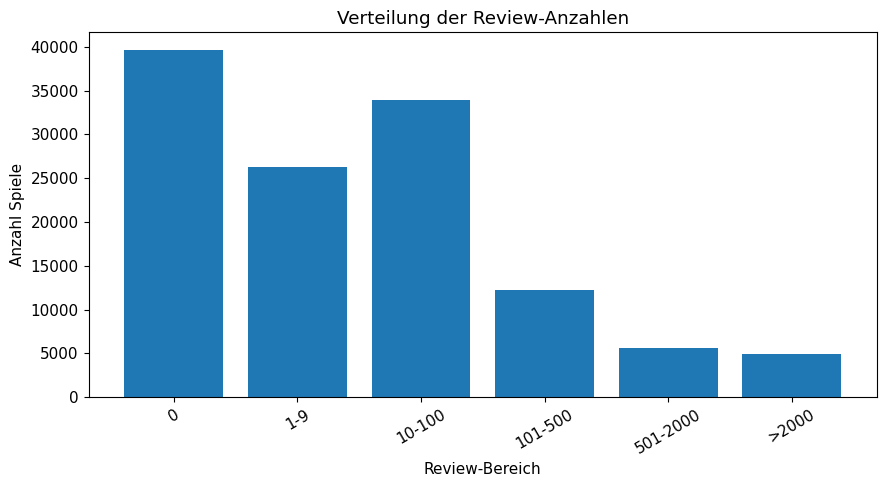

In [65]:
# Review-Verteilung
review_bins = [
    ("0", (df_raw["Total_reviews"] == 0).sum()),
    ("1-9", ((df_raw["Total_reviews"] >= 1) & (df_raw["Total_reviews"] < 10)).sum()),
    ("10-100", ((df_raw["Total_reviews"] >= 10) & (df_raw["Total_reviews"] <= 100)).sum()),
    ("101-500", ((df_raw["Total_reviews"] > 100) & (df_raw["Total_reviews"] <= 500)).sum()),
    ("501-2000", ((df_raw["Total_reviews"] > 500) & (df_raw["Total_reviews"] <= 2000)).sum()),
    (">2000", (df_raw["Total_reviews"] > 2000).sum()),
]

labels, counts = zip(*review_bins)

plt.figure(figsize=(9, 5))
plt.bar(labels, counts)
plt.title("Verteilung der Review-Anzahlen")
plt.xlabel("Review-Bereich")
plt.ylabel("Anzahl Spiele")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## 5. Datensatz filtern

Für das Projekt werden nur Spiele betrachtet, die folgende Bedingungen erfüllen:

- Indie-Spiel
- Preis größer als 0
- Anzahl Reviews zwischen 10 und 2000

Warum dieser Filter sinnvoll ist:

- Spiele mit 0 Reviews liefern kaum Information.
- Sehr große Spiele mit extrem vielen Reviews sind Ausreißer.
- Der Fokus liegt auf Indie-Spielen.


In [66]:
df_raw["Price"] = pd.to_numeric(df_raw["Price"], errors="coerce").fillna(0)

indie_mask = df_raw["Tags"].astype(str).str.contains("Indie", case=False, na=False)
paid_mask = df_raw["Price"] > 0
reviews_mask = (df_raw["Total_reviews"] >= 10) & (df_raw["Total_reviews"] <= 2000)

df = df_raw[indie_mask & paid_mask & reviews_mask].copy().reset_index(drop=True)

print(f"Gesamter Datensatz: {len(df_raw):,} Spiele")
print(f"Gefilterter Datensatz: {len(df):,} Spiele")
print("\nZielvariable nach Filter:")
print(df["Total_reviews"].describe().round(2))


Gesamter Datensatz: 122,611 Spiele
Gefilterter Datensatz: 27,083 Spiele

Zielvariable nach Filter:
count    27083.00
mean       174.93
std        316.85
min         10.00
25%         20.00
50%         47.00
75%        157.00
max       1998.00
Name: Total_reviews, dtype: float64


## 6. Explorative Datenanalyse

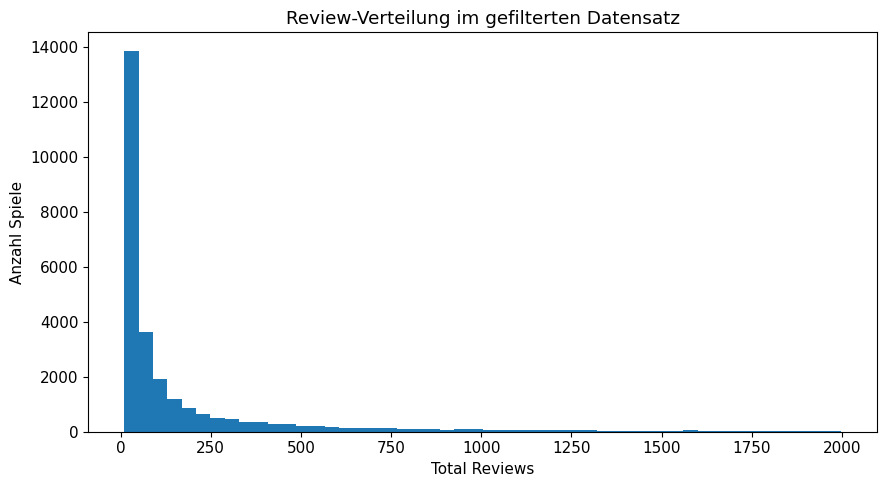

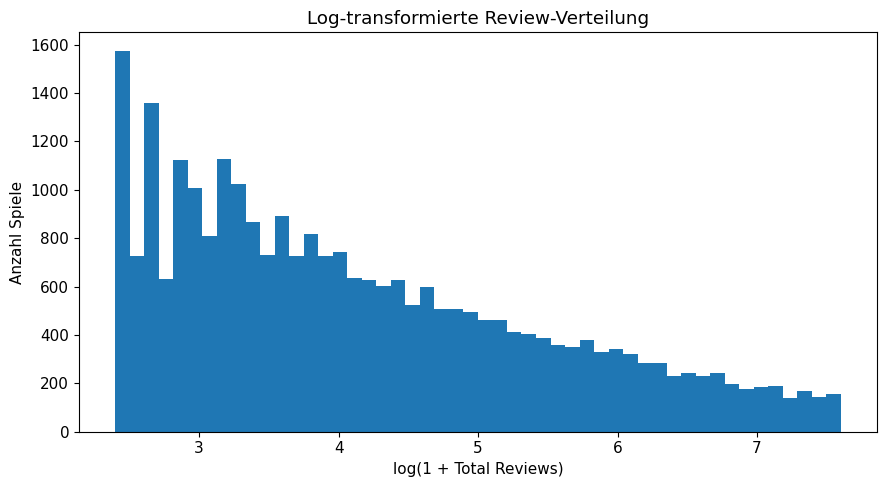

In [67]:
plt.figure(figsize=(9, 5))
plt.hist(df["Total_reviews"], bins=50)
plt.title("Review-Verteilung im gefilterten Datensatz")
plt.xlabel("Total Reviews")
plt.ylabel("Anzahl Spiele")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(np.log1p(df["Total_reviews"]), bins=50)
plt.title("Log-transformierte Review-Verteilung")
plt.xlabel("log(1 + Total Reviews)")
plt.ylabel("Anzahl Spiele")
plt.tight_layout()
plt.show()


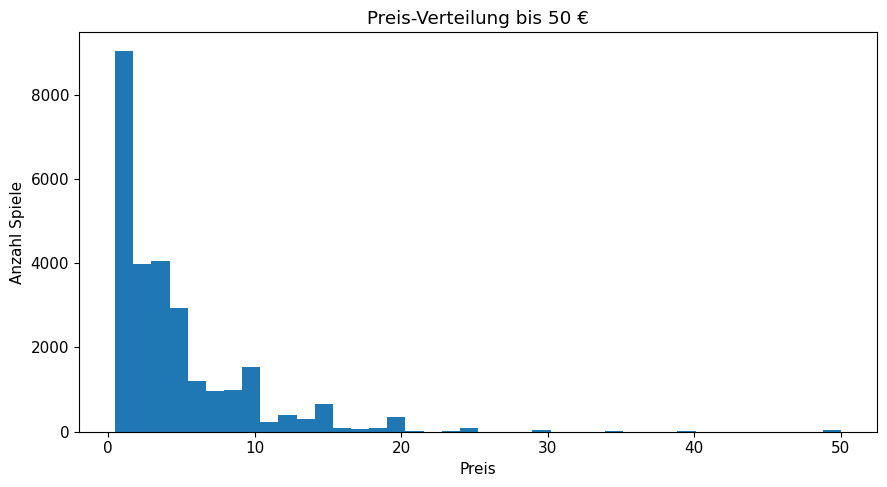

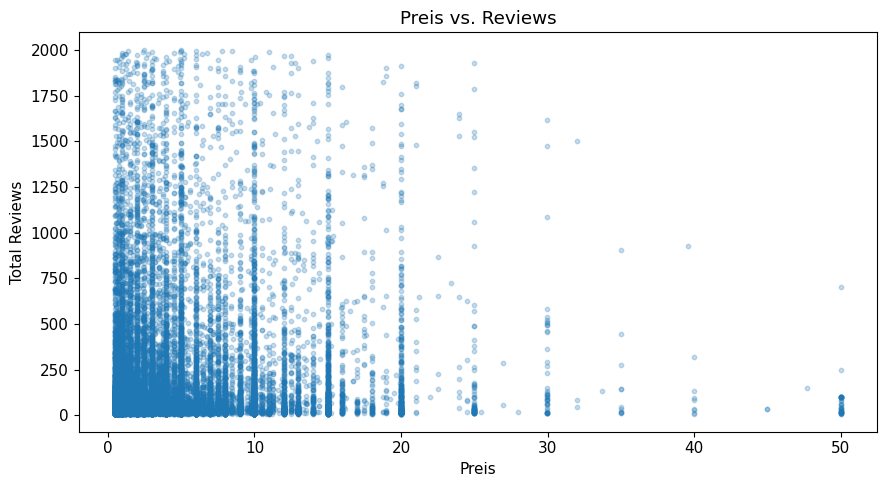

In [68]:
plt.figure(figsize=(9, 5))
plt.hist(df["Price"].clip(upper=50), bins=40)
plt.title("Preis-Verteilung bis 50 €")
plt.xlabel("Preis")
plt.ylabel("Anzahl Spiele")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(df["Price"].clip(upper=50), df["Total_reviews"], alpha=0.25, s=10)
plt.title("Preis vs. Reviews")
plt.xlabel("Preis")
plt.ylabel("Total Reviews")
plt.tight_layout()
plt.show()


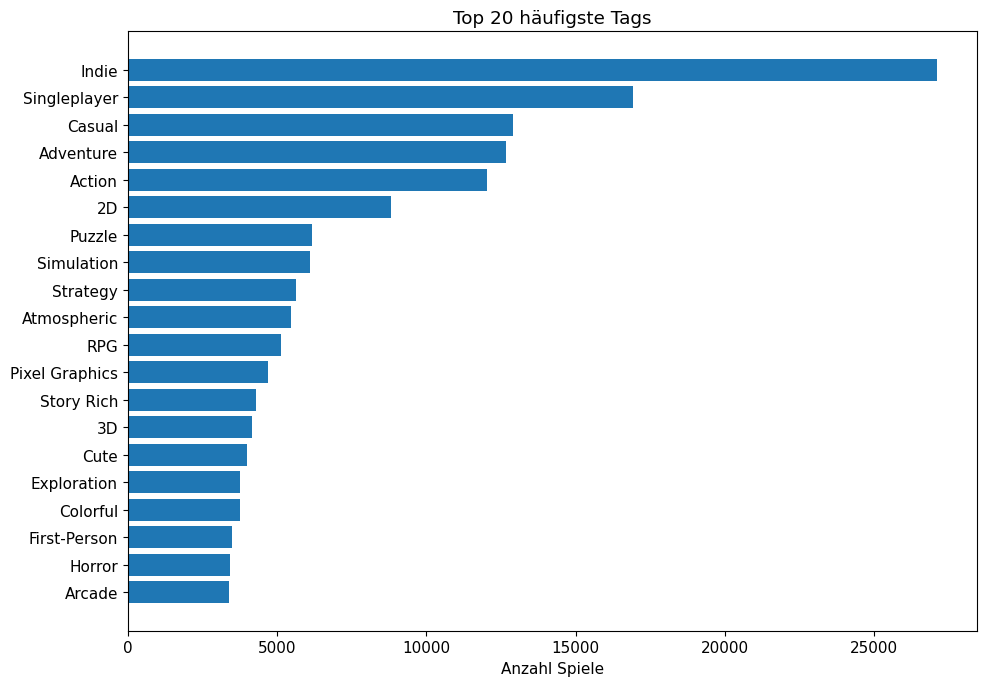

Tags
Indie             27083
Singleplayer      16920
Casual            12903
Adventure         12671
Action            12036
2D                 8822
Puzzle             6169
Simulation         6107
Strategy           5622
Atmospheric        5454
RPG                5136
Pixel Graphics     4693
Story Rich         4295
3D                 4159
Cute               3991
Exploration        3776
Colorful           3760
First-Person       3499
Horror             3431
Arcade             3390
Name: count, dtype: int64

In [69]:
all_tags = df["Tags"].dropna().astype(str).str.split(",").explode().str.strip()
top_tags = all_tags.value_counts().head(20)

plt.figure(figsize=(10, 7))
plt.barh(top_tags.index[::-1], top_tags.values[::-1])
plt.title("Top 20 häufigste Tags")
plt.xlabel("Anzahl Spiele")
plt.tight_layout()
plt.show()

top_tags


## 7. Feature Engineering

Es werden Text-Features und numerische Features erstellt.

**Text-Features:**

- Spielbeschreibung
- Tags
- Genres
- Kategorien

**Numerische Features:**

- Preis
- Anzahl Achievements
- Anzahl Tags
- Länge der Beschreibung
- Plattformen
- Release-Jahr


In [70]:
# Text kombinieren 
df["text_combined"] = (
    df["About the game"].fillna("").astype(str) + " " +
    df["Tags"].fillna("").astype(str) + " " +
    df["Genres"].fillna("").astype(str) + " " +
    df["Categories"].fillna("").astype(str)
)

# Zielvariable vorbereiten
df["Total_reviews"] = pd.to_numeric(df["Total_reviews"], errors="coerce").fillna(0)
df["Log_total_reviews"] = np.log1p(df["Total_reviews"])

# Numerische Features
df["Price"] = pd.to_numeric(df["Price"], errors="coerce").fillna(0)

df["Achievements_count"] = pd.to_numeric(df["Achievements"], errors="coerce").fillna(0)
df["Has_achievements"] = (df["Achievements_count"] > 0).astype(int)

df["Num_tags"] = df["Tags"].fillna("").astype(str).apply(
    lambda x: len([tag for tag in x.split(",") if tag.strip()]) if x else 0
)

df["Desc_length"] = df["About the game"].fillna("").astype(str).apply(len)

df["Is_windows"] = df["Windows"].astype(str).str.lower().isin(["true", "1", "yes"]).astype(int)
df["Is_mac"] = df["Mac"].astype(str).str.lower().isin(["true", "1", "yes"]).astype(int)
df["Is_linux"] = df["Linux"].astype(str).str.lower().isin(["true", "1", "yes"]).astype(int)

df["Release_year"] = pd.to_datetime(df["Release date"], errors="coerce").dt.year
df["Release_year"] = df["Release_year"].fillna(df["Release_year"].median())

df["Release_year"] = pd.to_datetime(
    df["Release date"],
    format="%b %d, %Y",
    errors="coerce"
).dt.year

df["Release_year"] = df["Release_year"].fillna(df["Release_year"].median())

print(df["Release_year"].head())
print(df["Release_year"].isna().sum())

numeric_features = [
    "Price",
    # "Achievements_count",
    "Has_achievements",
    "Num_tags",
    "Desc_length",
    "Is_windows",
    "Is_mac",
    "Is_linux",
    "Release_year"
]

df[numeric_features + ["Total_reviews", "Log_total_reviews"]].describe().round(2)

0    2021
1    2019
2    2023
3    2021
4    2024
Name: Release_year, dtype: int32
0


,Price,Has_achievements,Num_tags,Desc_length,Is_windows,Is_mac,Is_linux,Release_year,Total_reviews,Log_total_reviews
count,27083.00,27083.00,27083.00,27083.00,27083.0,27083.00,27083.00,27083.00,27083.00,27083.00
mean,4.63,0.69,13.46,1285.08,1.0,0.26,0.18,2019.63,174.93,4.17
std,7.07,0.46,6.16,914.65,0.0,0.44,0.39,3.22,316.85,1.33
min,0.49,0.00,1.00,0.00,1.0,0.00,0.00,1997.00,10.00,2.40
25%,0.99,0.00,7.00,685.00,1.0,0.00,0.00,2017.00,20.00,3.04
50%,2.99,1.00,15.00,1077.00,1.0,0.00,0.00,2020.00,47.00,3.87
75%,5.99,1.00,20.00,1624.00,1.0,1.00,0.00,2022.00,157.00,5.06
max,269.99,1.00,21.00,25646.00,1.0,1.00,1.00,2025.00,1998.00,7.60


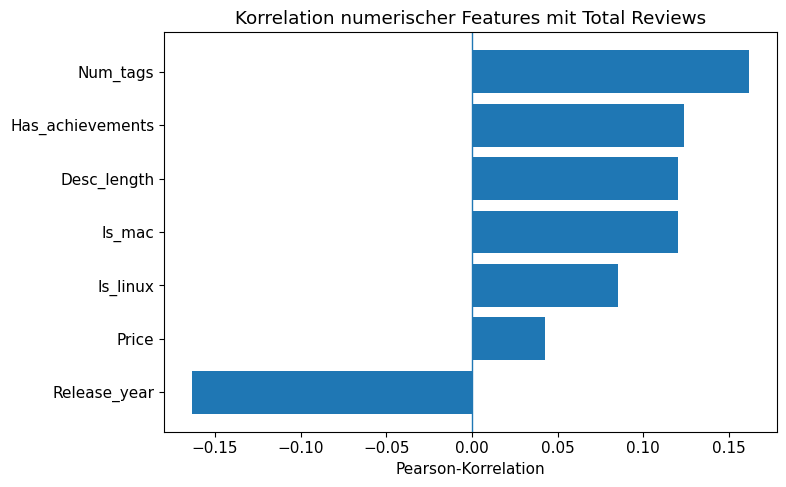

Release_year       -0.163509
Price               0.042328
Is_linux            0.085400
Is_mac              0.120064
Desc_length         0.120336
Has_achievements    0.123810
Num_tags            0.161755
Is_windows               NaN
Name: Total_reviews, dtype: float64

In [71]:
# normal reviews correlation

corr_reviews = df[numeric_features + ["Total_reviews"]].corr(numeric_only=True)["Total_reviews"]
corr_reviews = corr_reviews.drop("Total_reviews").sort_values()

plt.figure(figsize=(8, 5))
plt.barh(corr_reviews.index, corr_reviews.values)
plt.axvline(0, linewidth=1)
plt.title("Korrelation numerischer Features mit Total Reviews")
plt.xlabel("Pearson-Korrelation")
plt.tight_layout()
plt.show()

corr_reviews

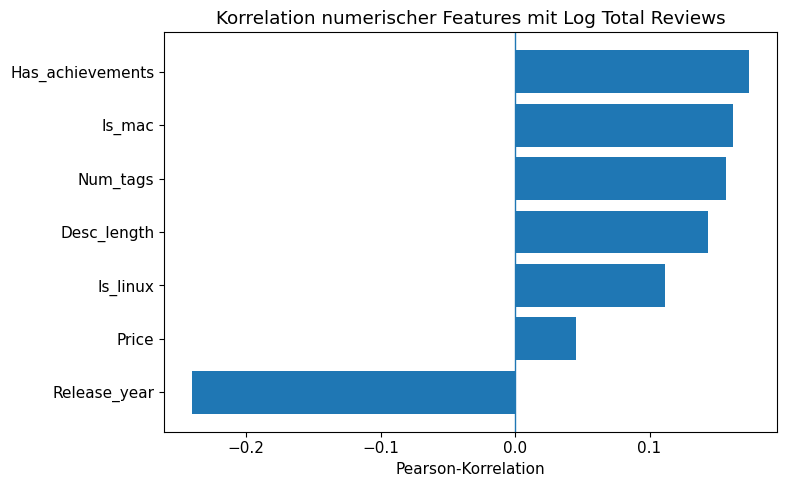

Release_year       -0.240474
Price               0.045353
Is_linux            0.111209
Desc_length         0.143824
Num_tags            0.157235
Is_mac              0.161941
Has_achievements    0.174084
Is_windows               NaN
Name: Log_total_reviews, dtype: float64

In [72]:
# log reviews correlation

corr_log_reviews = df[numeric_features + ["Log_total_reviews"]].corr(numeric_only=True)["Log_total_reviews"]
corr_log_reviews = corr_log_reviews.drop("Log_total_reviews").sort_values()

plt.figure(figsize=(8, 5))
plt.barh(corr_log_reviews.index, corr_log_reviews.values)
plt.axvline(0, linewidth=1)
plt.title("Korrelation numerischer Features mit Log Total Reviews")
plt.xlabel("Pearson-Korrelation")
plt.tight_layout()
plt.show()

corr_log_reviews

## 8. Train/Test-Split ohne Data Leakage

Wichtig: Der Train/Test-Split passiert **vor** TF-IDF.

Dadurch sieht der TF-IDF-Vektorisierer beim Lernen nur die Trainingsdaten und nicht die Testdaten.


In [73]:
X_text = df["text_combined"]

X_num = df[numeric_features].fillna(0)

y = np.log1p(df["Total_reviews"])

X_text_train, X_text_test, X_num_train, X_num_test, y_train, y_test = train_test_split(
    X_text,
    X_num,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE
)

# scaler = StandardScaler()
# X_num_train_scaled = scaler.fit_transform(X_num_train)
# X_num_test_scaled = scaler.transform(X_num_test)

# X_train = hstack([X_train_text_tfidf, csr_matrix(X_num_train_scaled)])
# X_test = hstack([X_test_text_tfidf, csr_matrix(X_num_test_scaled)])

# print(np.isnan(X_train.data).sum())
# print(np.isnan(X_test.data).sum())


In [74]:
# TF-IDF nur auf Trainingsdaten fitten
tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    stop_words="english"
)

X_train_text_tfidf = tfidf.fit_transform(X_text_train)
X_test_text_tfidf = tfidf.transform(X_text_test)

# Numerische Features skalieren
scaler = StandardScaler()
X_train_num_scaled = scaler.fit_transform(X_num_train)
X_test_num_scaled = scaler.transform(X_num_test)

# Text + numerische Features kombinieren
X_train = hstack([X_train_text_tfidf, csr_matrix(X_train_num_scaled)])
X_test = hstack([X_test_text_tfidf, csr_matrix(X_test_num_scaled)])

print("Feature-Matrix Training:", X_train.shape)
print("Feature-Matrix Test:", X_test.shape)


Feature-Matrix Training: (21666, 3008)
Feature-Matrix Test: (5417, 3008)


## 9. Hilfsfunktion für Evaluation

In [75]:
def evaluate_model(model_name, model, X_train, X_test, y_train, y_test):
    """Trainiert ein Modell und berechnet Metriken auf Original-Review-Skala."""
    model.fit(X_train, y_train)

    y_pred_log = model.predict(X_test)

    # Rücktransformation von log(1 + reviews) zu reviews
    y_true = np.expm1(y_test)
    y_pred = np.expm1(y_pred_log)

    # Negative Vorhersagen vermeiden
    y_pred = np.maximum(y_pred, 0)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    result = {
        "Modell": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    return result, y_true, y_pred


## 10. Modelle trainieren

### 10.1 Linear Regression / Ridge Regression

Ridge ist eine regularisierte lineare Regression.  
Sie ist stabiler als eine einfache Linear Regression, besonders bei sehr vielen TF-IDF-Features.


In [76]:
results = {}
predictions = {}

ridge_model = Ridge(alpha=1.0, random_state=RANDOM_STATE)

result, y_true, y_pred_ridge = evaluate_model(
    "Linear Regression (Ridge)",
    ridge_model,
    X_train,
    X_test,
    y_train,
    y_test
)

results["Linear Regression (Ridge)"] = result
predictions["Linear Regression (Ridge)"] = y_pred_ridge

print(result)


{'Modell': 'Linear Regression (Ridge)', 'MAE': 132.98940188576248, 'RMSE': np.float64(292.6880598043125), 'R2': 0.11855523651146405}


### 10.2 Random Forest Regressor

Random Forest kann nichtlineare Zusammenhänge lernen.  
Er ist aber bei sehr vielen Textfeatures oft langsamer als lineare Modelle oder XGBoost.


In [77]:
rf_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=18,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

result, y_true, y_pred_rf = evaluate_model(
    "Random Forest",
    rf_model,
    X_train,
    X_test,
    y_train,
    y_test
)

results["Random Forest"] = result
predictions["Random Forest"] = y_pred_rf

print(result)


{'Modell': 'Random Forest', 'MAE': 126.52977549029916, 'RMSE': np.float64(283.83996205332426), 'R2': 0.1710426803853321}


### 10.3 XGBoost Regressor

In [78]:
if XGBOOST_AVAILABLE:
    xgb_model = XGBRegressor(
        n_estimators=400,
        learning_rate=0.04,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        tree_method="hist",
        n_jobs=-1
    )

    result, y_true, y_pred_xgb = evaluate_model(
        "XGBoost",
        xgb_model,
        X_train,
        X_test,
        y_train,
        y_test
    )

    results["XGBoost"] = result
    predictions["XGBoost"] = y_pred_xgb

    print(result)
else:
    print("XGBoost wurde übersprungen, weil das Paket nicht installiert ist.")


{'Modell': 'XGBoost', 'MAE': 122.58962231376019, 'RMSE': np.float64(274.24245450366146), 'R2': 0.22615413733615497}


## 11. Modellvergleich

In [79]:
results_df = pd.DataFrame(results.values())
results_df = results_df.sort_values("MAE").reset_index(drop=True)

print("Modellvergleich auf Original-Review-Skala:")
display(results_df.round(3))

best_model_name = results_df.iloc[0]["Modell"]
print(f"🏆 Bestes Modell nach MAE: {best_model_name}")


Modellvergleich auf Original-Review-Skala:


,Modell,MAE,RMSE,R2
0,XGBoost,122.590,274.242,0.226
1,Random Forest,126.530,283.840,0.171
2,Linear Regression (Ridge),132.989,292.688,0.119


🏆 Bestes Modell nach MAE: XGBoost


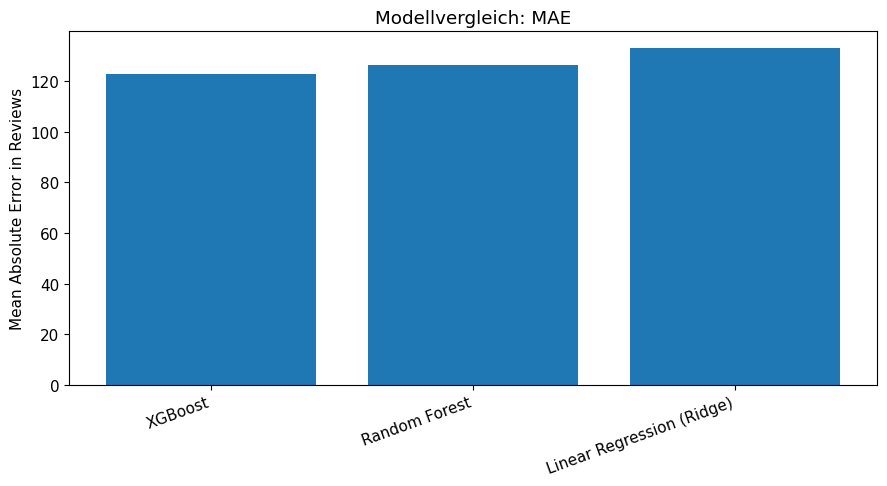

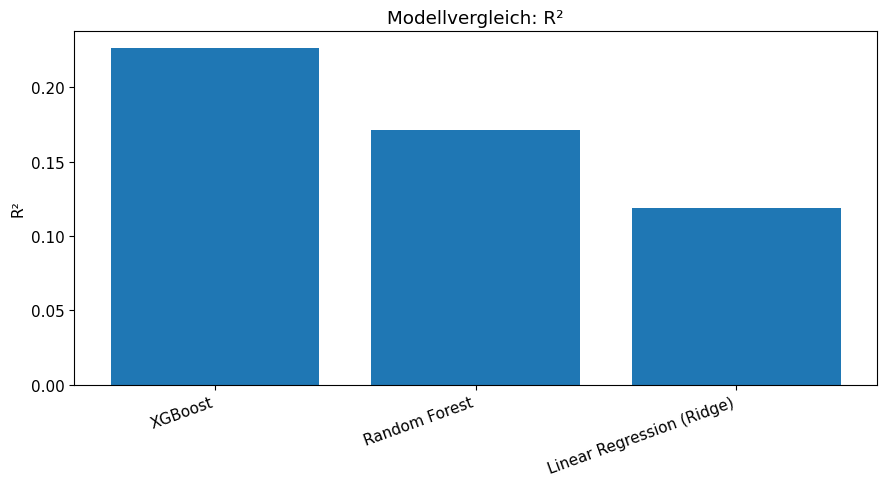

In [80]:
plt.figure(figsize=(9, 5))
plt.bar(results_df["Modell"], results_df["MAE"])
plt.title("Modellvergleich: MAE")
plt.ylabel("Mean Absolute Error in Reviews")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.bar(results_df["Modell"], results_df["R2"])
plt.title("Modellvergleich: R²")
plt.ylabel("R²")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


## 12. Visualisierung: echte vs. vorhergesagte Reviews

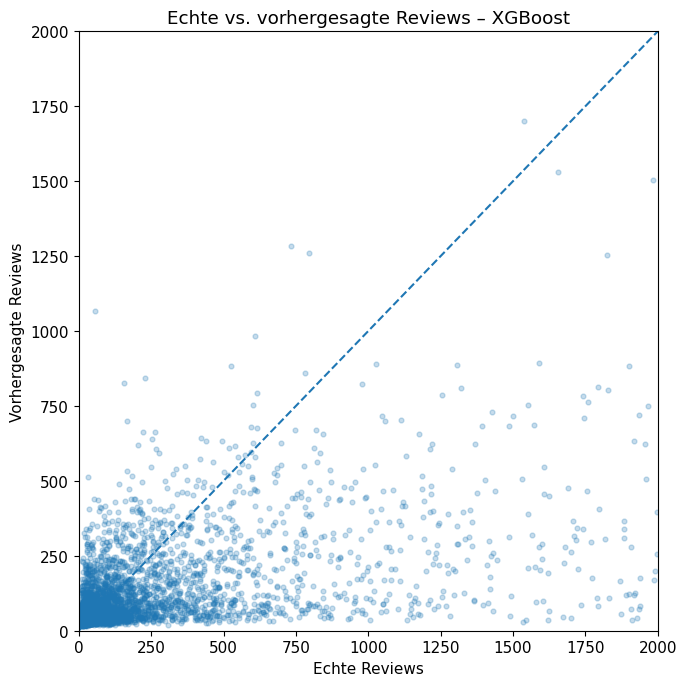

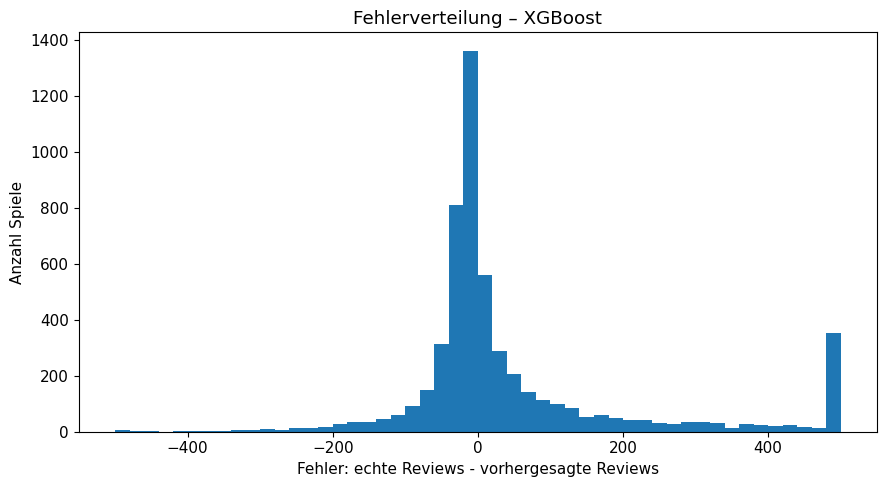

In [81]:
best_pred = predictions[best_model_name]

plt.figure(figsize=(7, 7))
plt.scatter(y_true, best_pred, alpha=0.25, s=12)
plt.plot([0, 2000], [0, 2000], linestyle="--")
plt.title(f"Echte vs. vorhergesagte Reviews – {best_model_name}")
plt.xlabel("Echte Reviews")
plt.ylabel("Vorhergesagte Reviews")
plt.xlim(0, 2000)
plt.ylim(0, 2000)
plt.tight_layout()
plt.show()

residuals = y_true - best_pred

plt.figure(figsize=(9, 5))
plt.hist(np.clip(residuals, -500, 500), bins=50)
plt.title(f"Fehlerverteilung – {best_model_name}")
plt.xlabel("Fehler: echte Reviews - vorhergesagte Reviews")
plt.ylabel("Anzahl Spiele")
plt.tight_layout()
plt.show()


## 13. Feature Importance

Bei XGBoost und Random Forest können Feature Importances betrachtet werden.  
Bei Ridge betrachten wir die absoluten Koeffizienten.

Wichtig: Feature Importance zeigt nur, welche Features im Modell wichtig waren.  
Sie beweist nicht automatisch einen kausalen Zusammenhang.


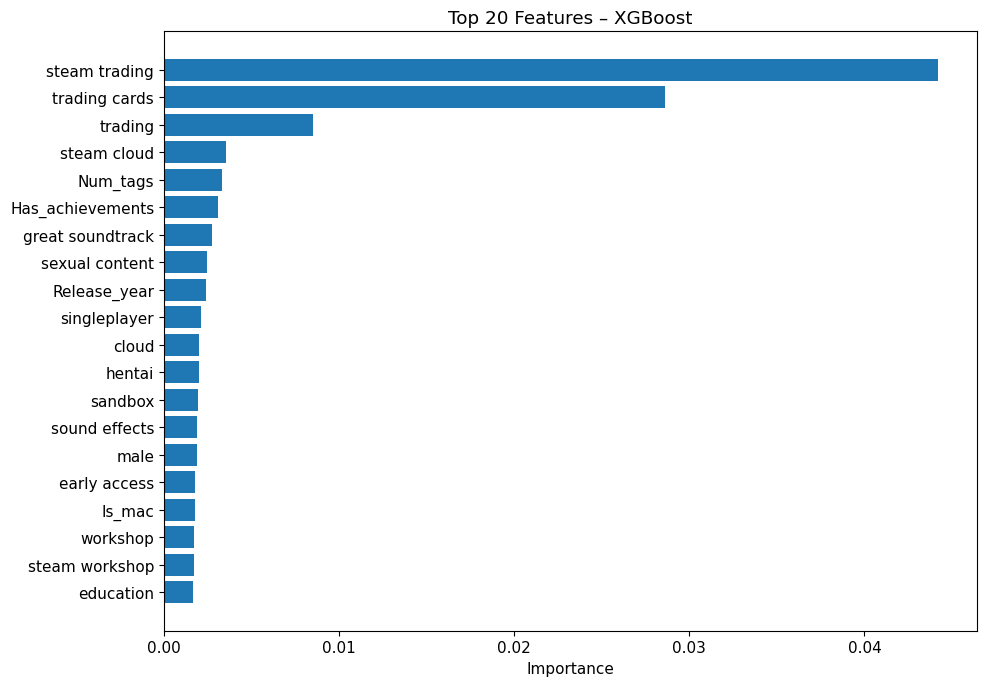

,Feature,Importance
2515,steam trading,0.044214
2734,trading cards,0.028603
2733,trading,0.008488
2513,steam cloud,0.003554
3002,Num_tags,0.003291
3001,Has_achievements,0.003063
1217,great soundtrack,0.002738
2354,sexual content,0.002437
3007,Release_year,0.002415
2399,singleplayer,0.002130


In [82]:
feature_names = list(tfidf.get_feature_names_out()) + numeric_features

def show_top_features(model_name, top_n=20):
    if model_name == "XGBoost" and XGBOOST_AVAILABLE:
        model = xgb_model
        importance = model.feature_importances_
    elif model_name == "Random Forest":
        model = rf_model
        importance = model.feature_importances_
    elif model_name == "Linear Regression (Ridge)":
        model = ridge_model
        importance = np.abs(model.coef_)
    else:
        print("Keine Feature Importance verfügbar.")
        return None

    fi = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    }).sort_values("Importance", ascending=False).head(top_n)

    plt.figure(figsize=(10, 7))
    plt.barh(fi["Feature"][::-1], fi["Importance"][::-1])
    plt.title(f"Top {top_n} Features – {model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    return fi

top_features = show_top_features(best_model_name, top_n=20)
top_features


## 14. Fehleranalyse

In [83]:
error_df = pd.DataFrame({
    "Name": df.loc[X_text_test.index, "Name"].values if "Name" in df.columns else X_text_test.index.astype(str),
    "Echte Reviews": y_true,
    "Vorhergesagte Reviews": best_pred,
    "Absoluter Fehler": np.abs(y_true - best_pred),
    "Text": X_text_test.values
})

error_df = error_df.sort_values("Absoluter Fehler", ascending=False)

print("Top 10 größte Fehler:")
display(error_df[["Name", "Echte Reviews", "Vorhergesagte Reviews", "Absoluter Fehler"]].head(10).round(1))


Top 10 größte Fehler:


,Name,Echte Reviews,Vorhergesagte Reviews,Absoluter Fehler
13531,Cultivation Story: Reincarnation,1930.0,42.299999,1887.7
24404,Small Saga,1911.0,37.000000,1874.0
16594,KIDS,1934.0,73.500000,1860.5
9577,Everhood 2,1938.0,83.500000,1854.5
5001,The Political Process,1908.0,71.900002,1836.1
17468,Genesis Noir,1988.0,169.600006,1818.4
14529,Spark the Electric Jester 3,1873.0,56.599998,1816.4
3979,Lemon Cake,1917.0,119.599998,1797.4
1175,Bad Guys at School,1920.0,127.500000,1792.5
7842,Choice of Robots,1989.0,200.899994,1788.1


## 15. Demo: Reviews für ein neues Spiel vorhersagen

Die Funktion nutzt das beste trainierte Modell aus dem Vergleich.


In [84]:
def predict_reviews(description, tags, genres="", categories="", price=9.99, achievements=0,
                    windows=True, mac=False, linux=False, release_year=2026):
    text = f"{description} {tags} {genres} {categories}"

    X_text_new = tfidf.transform([text])

    num_values = pd.DataFrame([{
        "Price": price,
        "Has_achievements": int(achievements > 0),
        "Num_tags": len([tag for tag in tags.split(",") if tag.strip()]),
        "Desc_length": len(description),
        "Is_windows": int(windows),
        "Is_mac": int(mac),
        "Is_linux": int(linux),
        "Release_year": release_year
    }])[numeric_features]

    X_num_new = scaler.transform(num_values)
    X_new = hstack([X_text_new, csr_matrix(X_num_new)])

    if best_model_name == "XGBoost" and XGBOOST_AVAILABLE:
        model = xgb_model
    elif best_model_name == "Random Forest":
        model = rf_model
    else:
        model = ridge_model

    pred_log = model.predict(X_new)[0]
    pred_log = np.clip(pred_log, 0, 10)
    pred_reviews = max(0, np.expm1(pred_log))

    return round(pred_reviews)

examples = [
    {
        "description": "A dark atmospheric horror game with puzzle solving and survival mechanics.",
        "tags": "Horror, Survival, Atmospheric, Puzzle, Indie, Singleplayer",
        "genres": "Adventure, Indie",
        "price": 14.99
    },
    {
        "description": "A colorful casual 2D platformer with cute characters and simple controls.",
        "tags": "Casual, Platformer, Colorful, Cute, Indie",
        "genres": "Casual, Indie",
        "price": 4.99
    },
    {
        "description": "Deep turn-based strategy RPG with complex systems, base building and tactical battles.",
        "tags": "Strategy, RPG, Turn-Based, Base Building, Tactical, Indie",
        "genres": "Strategy, RPG, Indie",
        "price": 19.99
    }
]

for example in examples:
    pred = predict_reviews(**example)
    print(f"{example['genres']:25s} | Preis: {example['price']:5.2f} € | Vorhersage: {pred:,} Reviews")


Adventure, Indie          | Preis: 14.99 € | Vorhersage: 31 Reviews
Casual, Indie             | Preis:  4.99 € | Vorhersage: 20 Reviews
Strategy, RPG, Indie      | Preis: 19.99 € | Vorhersage: 30 Reviews


## 16. Fazit

In diesem Notebook wurde ein Machine-Learning-Workflow zur Vorhersage von Steam-Reviews umgesetzt.

### Was wurde gemacht?

- Datensatz geladen und geprüft
- Zielvariable `Total_reviews` erstellt
- Indie-Spiele mit 10 bis 2000 Reviews gefiltert
- Explorative Datenanalyse durchgeführt
- Textfeatures mit TF-IDF erstellt
- Data Leakage vermieden, weil TF-IDF nur auf Trainingsdaten gefittet wurde
- Drei Modelle verglichen:
  - Linear Regression / Ridge
  - Random Forest
  - XGBoost
- Ergebnisse mit MAE, RMSE und R² bewertet
- Feature Importance und Fehleranalyse ergänzt

### Interpretation

Das beste Modell ist das Modell mit dem niedrigsten MAE.  
Der MAE zeigt, um wie viele Reviews das Modell im Durchschnitt danebenliegt.

### Grenzen des Ansatzes

- Reviews sind nur ein Proxy für Sales, keine echten Verkaufszahlen.
- Sehr erfolgreiche Spiele sind schwer vorherzusagen.
- Marketing, Publisher, Wishlists und externe Aufmerksamkeit fehlen im Datensatz.
- Textinformationen allein erklären den Erfolg nur teilweise.

### Nächster sinnvoller Schritt

Als nächstes kann ein Textmodell wie **DistilBERT** getestet werden.  
Dadurch kann geprüft werden, ob ein Sprachmodell die Spielbeschreibung besser versteht als TF-IDF.


In [86]:
print(results_df)

                      Modell         MAE        RMSE        R2
0                    XGBoost  122.589622  274.242455  0.226154
1              Random Forest  126.529775  283.839962  0.171043
2  Linear Regression (Ridge)  132.989402  292.688060  0.118555
